# Dataset Amazon
Preprocesamiento y análisis exploratorio de ventas mensuales en Amazon (abril 2024 – marzo 2026).

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Carga de datos

Para cargar los datos, uso `glob` junto con un bucle y expresiones regulares para leer todos los archivos de manera automática y fácil de mantener. Esto me permite incorporar nuevos meses sin necesidad de modificar el código.

In [ ]:
meses_map = {
    'enero':      'Enero',
    'febrero':    'Febrero',
    'marzo':      'Marzo',
    'abril':      'Abril',
    'mayo':       'Mayo',
    'junio':      'Junio',
    'julio':      'Julio',
    'agosto':     'Agosto',
    'sep':        'Septiembre',
    'septiembre': 'Septiembre',
    'octubre':    'Octubre',
    'octu':       'Octubre',
    'novi':       'Noviembre',
    'noviembre':  'Noviembre',
    'dici':       'Diciembre',
    'diciembre':  'Diciembre',
}

dfs = []

for ruta in sorted(glob.glob('/content/BusinessReport-*.csv')):
    # Extrae año (4 dígitos) y el token de mes (todo lo que queda entre los guiones)
    match = re.search(
        r'BusinessReport-(?:\d+\s+dias\s+)?([a-záéíóúñ]+)-?(\d{4})',
        ruta,
        flags=re.IGNORECASE
    )
    if not match:
        print(f'No se pudo parsear: {ruta}')
        continue

    nombre_mes = match.group(1).lower().strip()
    anio       = int(match.group(2))

    df = pd.read_csv(ruta)
    df['Anio'] = anio
    df['Mes']  = meses_map.get(nombre_mes, nombre_mes.capitalize())
    dfs.append(df)

df_total = pd.concat(dfs, ignore_index=True)
print(f'{len(dfs)} ficheros cargados, con {len(df_total):,} filas en total.')

No se pudo parsear: /content/BusinessReport-15 dias marzo 2026.csv
23 ficheros cargados, con 2,683 filas en total.


## 3. Columna `fecha` como datetime

Para manejar las series temporales, creo una columna `fecha` de tipo datetime que combina el `Anio` y el `Mes`, añadiendo el primer día de cada mes. Esto me permite ordenar cronológicamente y calcular medias móviles.

In [ ]:
meses_a_num = {
    'Enero':1, 'Febrero':2, 'Marzo':3, 'Abril':4,
    'Mayo':5,  'Junio':6,   'Julio':7, 'Agosto':8,
    'Septiembre':9, 'Octubre':10, 'Noviembre':11, 'Diciembre':12,
}

df_total['fecha'] = pd.to_datetime(
    df_total['Anio'].astype(str) + '-' +
    df_total['Mes'].map(meses_a_num).astype(str) + '-01'
)

# Ordenar cronológicamente por producto y fecha (imprescindible para series temporales)
df_total = df_total.sort_values(['ASIN (child)', 'fecha']).reset_index(drop=True)

print(df_total[['ASIN (child)', 'Mes', 'Anio', 'fecha']].head(10))
print(f"\nRango temporal: {df_total['fecha'].min().date()} → {df_total['fecha'].max().date()}")


  ASIN (child)         Mes  Anio      fecha
0   B01BAUMXX0       Abril  2024 2024-04-01
1   B01BAUMXX0        Mayo  2024 2024-05-01
2   B01BAUMXX0       Junio  2024 2024-06-01
3   B01BAUMXX0       Julio  2024 2024-07-01
4   B01BAUMXX0      Agosto  2024 2024-08-01
5   B01BAUMXX0  Septiembre  2024 2024-09-01
6   B01BAUMXX0     Octubre  2024 2024-10-01
7   B01BAUMXX0   Noviembre  2024 2024-11-01
8   B01BAUMXX0   Diciembre  2024 2024-12-01
9   B01BAUMXX0       Enero  2025 2025-01-01

Rango temporal: 2024-04-01 → 2026-02-01


## 4. Limpieza de columnas numéricas

Las columnas numéricas como `Unidades encargadas` estaban en formato de texto. Las convierto a numérico, incluyendo las columnas de ventas. Para verificar que los rangos sean correctos después de la conversión (considerando el formato europeo de números), utilizo `describe()`.

In [ ]:
def limpiar_euros(serie):
    """Quita €, separador de miles (.) y convierte coma decimal a punto."""
    return (
        serie.astype(str)
        .str.replace('€', '', regex=False)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .str.strip()
        .replace('nan', np.nan)
        .astype(float)
    )

def limpiar_entero(serie):
    """Quita separador de miles y convierte a int."""
    return (
        serie.astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace('nan', np.nan)
        .astype(float)
        .astype('Int64')
    )

# Columnas monetarias
for col in ['Ventas de productos enviados',
            'Ventas de productos encargados',
            'Ventas de productos encargados: B2B']:
    df_total[col] = limpiar_euros(df_total[col])

# Columnas enteras (tráfico + unidades — la target incluida)
for col in ['Sesiones: total', 'Visitas: total', 'Unidades encargadas']:
    df_total[col] = limpiar_entero(df_total[col])

# Verifico los rangos para asegurar la coherencia de los números después de la limpieza.
print("Verificación tras limpieza:")
print(df_total[['Unidades encargadas',
                'Ventas de productos encargados',
                'Sesiones: total',
                'Visitas: total']].describe().round(2))

Verificación tras limpieza:
       Unidades encargadas  Ventas de productos encargados  Sesiones: total  \
count               2683.0                         2683.00           2683.0   
mean                 13.93                          262.29           280.28   
std                  38.52                          689.19           467.75   
min                    0.0                            0.00              0.0   
25%                    1.0                            9.99             34.5   
50%                    4.0                           64.00            118.0   
75%                   14.0                          238.79            344.5   
max                 1085.0                        17129.16           8658.0   

       Visitas: total  
count          2683.0  
mean            400.6  
std            685.74  
min               0.0  
25%              45.5  
50%             163.0  
75%             485.0  
max           13136.0  


## 5. Distribución del target: `Unidades encargadas`

`Unidades encargadas` es una variable continua/discreta, no categórica. Para explorar su distribución de manera adecuada, utilizo `describe()` y un histograma, ya que `value_counts()` no es apropiado para este tipo de variable.

Estadísticas del target 'Unidades encargadas':
count       2683.0
mean      13.92732
std      38.517943
min            0.0
25%            1.0
50%            4.0
75%           14.0
max         1085.0
Name: Unidades encargadas, dtype: Float64


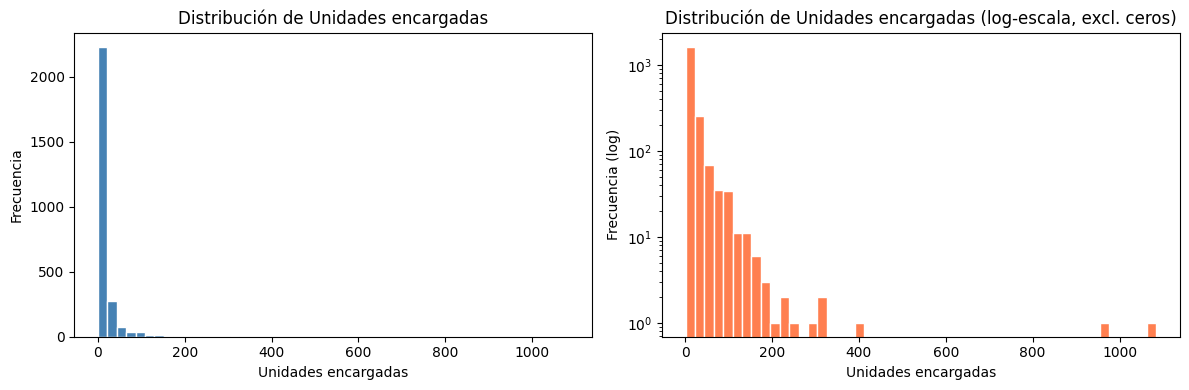

In [ ]:
# Uso describe y un histograma para visualizar esta variable numérica.
print("Estadísticas del target 'Unidades encargadas':")
print(df_total['Unidades encargadas'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma (escala normal)
axes[0].hist(df_total['Unidades encargadas'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Unidades encargadas')
axes[0].set_xlabel('Unidades encargadas')
axes[0].set_ylabel('Frecuencia')

# Histograma en log (útil cuando hay muchos ceros y algunos valores grandes)
vals = df_total['Unidades encargadas'].dropna()
axes[1].hist(vals[vals > 0], bins=50, color='coral', edgecolor='white', log=True)
axes[1].set_title('Distribución de Unidades encargadas (log-escala, excl. ceros)')
axes[1].set_xlabel('Unidades encargadas')
axes[1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

## 6. Vista general del dataset limpio

In [ ]:
print(f"Forma del dataset: {df_total.shape}")
print(f"Rango temporal:    {df_total['fecha'].min().date()} → {df_total['fecha'].max().date()}")
print(f"Productos únicos:  {df_total['ASIN (child)'].nunique()}")
print(f"\nTipos de datos:")
print(df_total.dtypes)
print(f"\n% valores faltantes:")
print((df_total.isna().mean() * 100).round(2))


Forma del dataset: (2683, 13)
Rango temporal:    2024-04-01 → 2026-02-01
Productos únicos:  191

Tipos de datos:
ASIN (child)                                   object
Título                                         object
Sesiones: total                                 Int64
Visitas: total                                  Int64
Unidades encargadas                             Int64
Unidades encargadas - B2B                       int64
Ventas de productos encargados                float64
Ventas de productos encargados: B2B           float64
Unidades reembolsadas                           int64
Ventas de productos enviados                  float64
Anio                                            int64
Mes                                            object
fecha                                  datetime64[ns]
dtype: object

% valores faltantes:
ASIN (child)                           0.0
Título                                 0.0
Sesiones: total                        0.0
Visitas: total      

## 7. Matriz de correlación (variables relevantes)

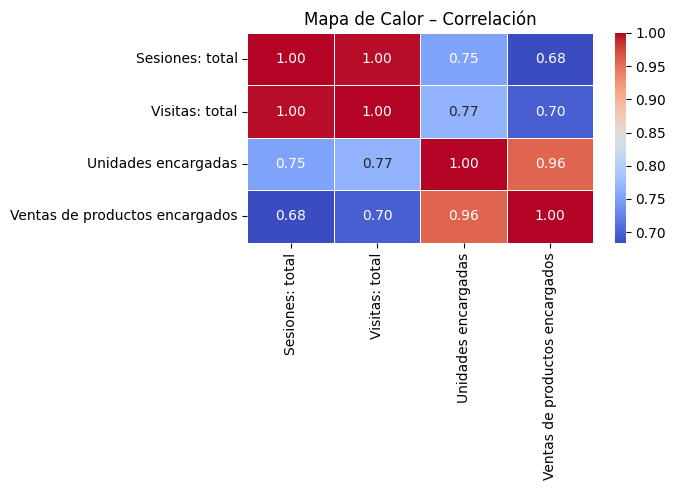

In [ ]:
relevant_cols = [
    'Sesiones: total', 'Visitas: total',
    'Unidades encargadas', 'Ventas de productos encargados'
]
corr_matrix = df_total[relevant_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor – Correlación')
plt.tight_layout()
plt.show()


## 8. Scatter plots

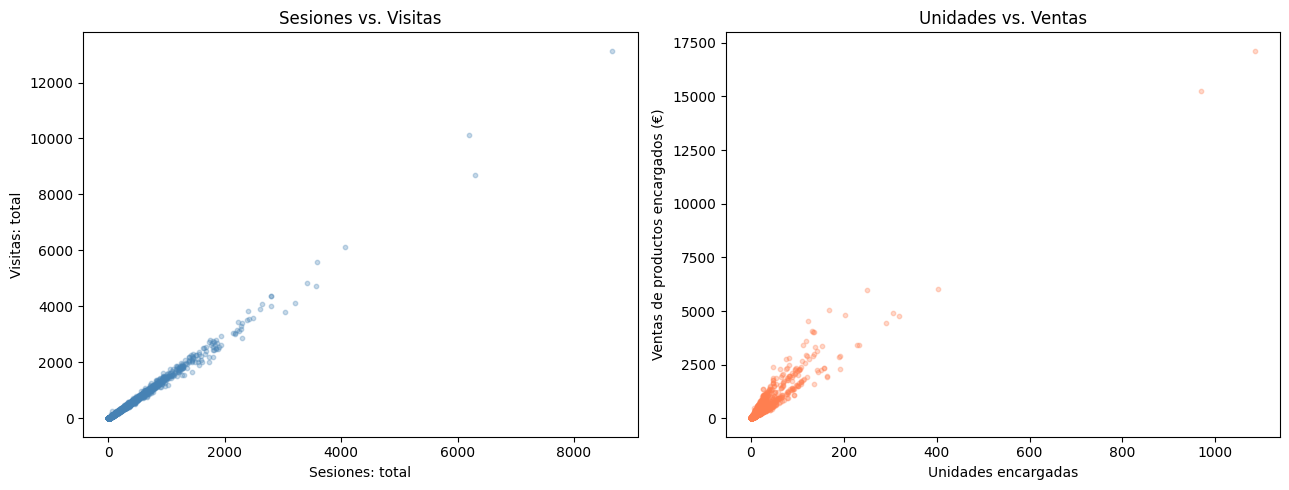

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_total['Sesiones: total'], df_total['Visitas: total'],
                alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('Sesiones: total')
axes[0].set_ylabel('Visitas: total')
axes[0].set_title('Sesiones vs. Visitas')

axes[1].scatter(df_total['Unidades encargadas'],
                df_total['Ventas de productos encargados'],
                alpha=0.3, s=10, color='coral')
axes[1].set_xlabel('Unidades encargadas')
axes[1].set_ylabel('Ventas de productos encargados (€)')
axes[1].set_title('Unidades vs. Ventas')

plt.tight_layout()
plt.show()


## 9. Ventas totales por mes (orden cronológico)

Usamos la columna `fecha` para ordenar correctamente el eje temporal.

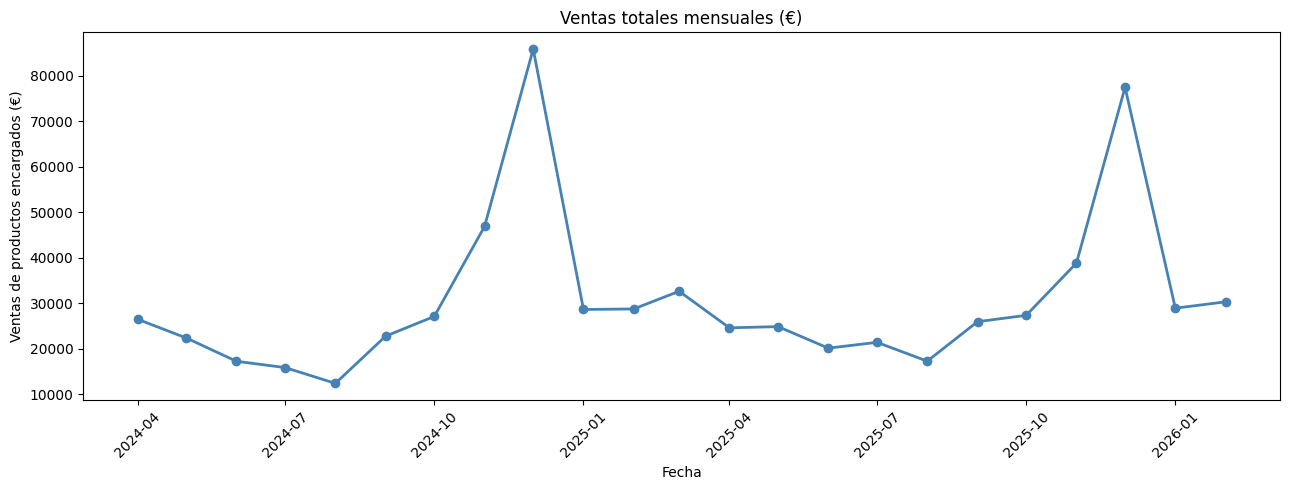

In [ ]:
ventas_mes = (
    df_total.groupby('fecha')['Ventas de productos encargados']
    .sum()
    .reset_index()
    .sort_values('fecha')
)

plt.figure(figsize=(13, 5))
plt.plot(ventas_mes['fecha'], ventas_mes['Ventas de productos encargados'],
         marker='o', linewidth=2, color='steelblue')
plt.title('Ventas totales mensuales (€)')
plt.xlabel('Fecha')
plt.ylabel('Ventas de productos encargados (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 10. Top 5 productos más vendidos en Diciembre

Top 5 productos más vendidos en Diciembre:


,ASIN (child),Título,Unidades encargadas
0,B0DK1TFZQ8,Papel de regalo kraft en rollo de 62CM x 25M p...,2054
1,B0D98591PQ,Papel de regalo kraft en rollo de 62CM x 25M c...,636
2,B0CWPHQ3QM,Rollo de papel de regalo 60CM x 25M Lunar Plat...,481
3,B0D1GQ9KZ5,Rollo de papel Kraft natural verjurado. Bobina...,344
4,B0CWPKB11X,Rollo de papel de regalo 60CM x 25M Lunar Oro....,320


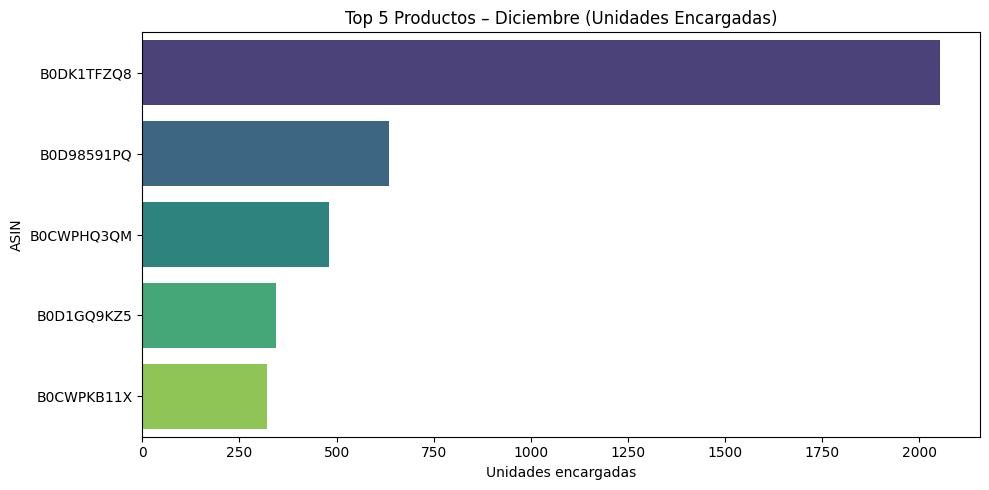

In [ ]:
dic_df = df_total[df_total['Mes'] == 'Diciembre']
top5 = (
    dic_df.groupby(['ASIN (child)', 'Título'])['Unidades encargadas']
    .sum().nlargest(5).reset_index()
)

print("Top 5 productos más vendidos en Diciembre:")
display(top5)

plt.figure(figsize=(10, 5))
sns.barplot(x='Unidades encargadas', y='ASIN (child)', data=top5,
            palette='viridis', hue='ASIN (child)', legend=False)
plt.title('Top 5 Productos – Diciembre (Unidades Encargadas)')
plt.xlabel('Unidades encargadas')
plt.ylabel('ASIN')
plt.tight_layout()
plt.show()


## 11. Guardado del dataset limpio

In [ ]:
df_total.to_csv('/content/drive/MyDrive/DatasetAmazon/df_total_limpio.csv', index=False)
print("Dataset guardado correctamente.")

Dataset guardado correctamente.


In [ ]:
for col in df_total.columns:
    print(col)

ASIN (child)
Título
Sesiones: total
Unidades encargadas
Unidades encargadas - B2B
Ventas de productos encargados
Ventas de productos encargados: B2B
Unidades reembolsadas
Ventas de productos enviados
Anio
Mes
